In [2]:
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
from miseval import evaluate
import skimage as ski
import pandas as pd
from glob import glob
import os

In [113]:
# a function for vusualisation and evaluation. 
def analysis(image_path, mask_path, true_mask_path=None, image_title='image', cbar=False):
  # Input image file name
  image_filename = image_path
  image = ski.io.imread(image_filename)
  # Input the mask file name
  mask_filename = mask_path
  mask = ski.io.imread(mask_filename)

  if true_mask_path is not None:
    # Input the true mask file name
    true_msk_filename = true_mask_path
    true_mask = ski.io.imread(true_msk_filename)
    
  # image
  plt.figure(figsize=(10,10))
  plt.subplot(131)
  plt.imshow(image)
  plt.title(image_title)

  cmap = 'Set2'
  # the image with masks
  plt.subplot(132)
  sns.heatmap(mask, xticklabels=False, yticklabels=False,alpha=0.5, cbar=cbar, cmap=cmap)
  plt.imshow(image)
  plt.title("predicted masks")

  # # masks
  # plt.subplot(133)
  # sns.heatmap(gray_img, xticklabels=False, yticklabels=False, cbar=False, cmap="mako")

  if true_mask_path is not None:
    # true masks
    plt.subplot(133)
    sns.heatmap(true_mask, xticklabels=False, yticklabels=False,alpha=0.5, cbar=cbar, cmap=cmap)
    plt.imshow(image)
    plt.title("true masks")


  plt.tight_layout()
  plt.show()
  
  

  if true_mask_path is not None:
    real_mask = ski.io.imread(true_msk_filename)
    pred_mask = ski.io.imread(mask_filename)
    dice_list = evaluate(real_mask, pred_mask, metric='DSC', multi_class=True, n_classes=6)
    iou_list = evaluate(real_mask, pred_mask, metric='IoU', multi_class=True, n_classes=6)
    sensitivity_list = evaluate(real_mask, pred_mask, metric='SENS', multi_class=True, n_classes=6)
    specificity_list = evaluate(real_mask, pred_mask, metric='SPEC', multi_class=True, n_classes=6)

    metrics_list = [dice_list, iou_list, sensitivity_list, specificity_list]
    rows = ['DSC', 'IoU', 'Sens', 'Spec']
    columns = ['0:BG/ILM','1:ILM-OPL','2:OPL-ISOS','3:ISOS-IBRPE','4:IBRPE-OBRPE','5:OBRPE/BG']
    df_metrics = pd.DataFrame(metrics_list, columns=columns, index=rows)

    print('Evaluation metrics')
    print('\n')
    print(df_metrics)
    print('\n')
    print('DSC...Dice Similarity Coefficient, ', 'IoU...Intersection-over-Union, ','Sens...Sensitivity, ','Spec...Specificity')
    # print('Multi-class Dice Similarity Coefficient between predicted and true masks:', dice_list)
    # print('Intersection Over Union:', iou_list)
    # print('Sensitivity:', sensitivity_list)
    # print('Specificity:', specificity_list)

# Noise

## Original

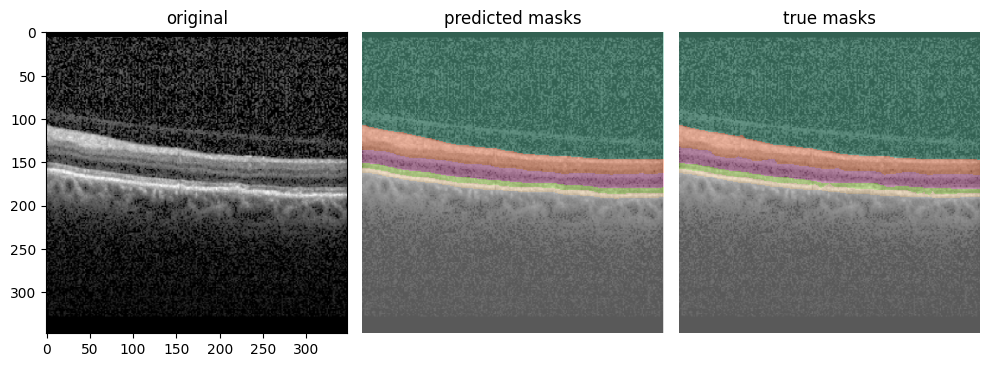

Evaluation metrics


      0:BG/ILM  1:ILM-OPL  2:OPL-ISOS  3:ISOS-IBRPE  4:IBRPE-OBRPE  5:OBRPE/BG
DSC   0.998994   0.969910    0.947938      0.889431       0.886432    0.997991
IoU   0.997991   0.941577    0.901028      0.800879       0.796029    0.995991
Sens  0.999315   0.978073    0.928033      0.910090       0.865554    0.998752
Spec  0.999167   0.997597    0.998555      0.997708       0.998505    0.997476


DSC...Dice Similarity Coefficient,  IoU...Intersection-over-Union,  Sens...Sensitivity,  Spec...Specificity


In [114]:
analysis("test_images/0001.png", "eval_outputs/0001_out.png", "test_masks/0001.png", image_title="original")

## Speckle noise

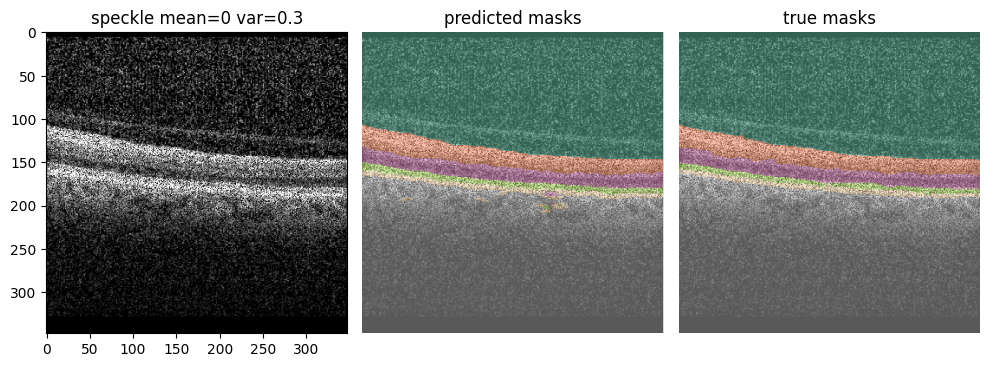

Evaluation metrics


      0:BG/ILM  1:ILM-OPL  2:OPL-ISOS  3:ISOS-IBRPE  4:IBRPE-OBRPE  5:OBRPE/BG
DSC   0.998683   0.965454    0.939898      0.858188       0.754760    0.993517
IoU   0.997370   0.933215    0.886610      0.751603       0.606116    0.987118
Sens  0.998523   0.966615    0.938801      0.937063       0.807164    0.988008
Spec  0.999274   0.997781    0.997161      0.995852       0.994322    0.999180


DSC...Dice Similarity Coefficient,  IoU...Intersection-over-Union,  Sens...Sensitivity,  Spec...Specificity


In [99]:
analysis("noisy_images/0001_speckle_m0v0.3.png", "eval_outputs/0001_speckle_m0v0.3_out.png", "test_masks/0001.png", image_title="speckle mean=0 var=0.3")

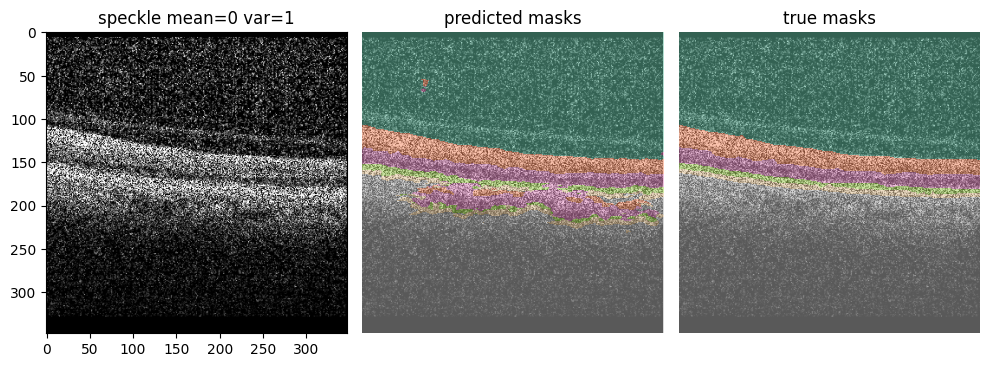

Evaluation metrics


      0:BG/ILM  1:ILM-OPL  2:OPL-ISOS  3:ISOS-IBRPE  4:IBRPE-OBRPE  5:OBRPE/BG
DSC   0.997621   0.889486    0.640681      0.638438       0.379870    0.920015
IoU   0.995253   0.800967    0.471325      0.468901       0.234468    0.851877
Sens  0.996340   0.960390    0.918880      0.824675       0.500000    0.853825
Spec  0.999314   0.987662    0.954203      0.987246       0.980616    0.997918


DSC...Dice Similarity Coefficient,  IoU...Intersection-over-Union,  Sens...Sensitivity,  Spec...Specificity


In [100]:
analysis("noisy_images/0001_speckle_m0v1.png", "eval_outputs/0001_speckle_m0v1_out.png", "test_masks/0001.png", image_title="speckle mean=0 var=1")

# OCTDL

## Disease

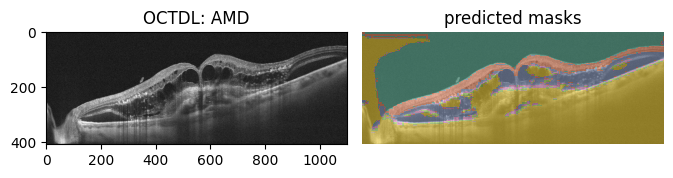

In [101]:
analysis('octdl/raw/amd_1163930_2.jpg', 'eval_outputs/amd_1163930_2_out.jpg', image_title='OCTDL: AMD')

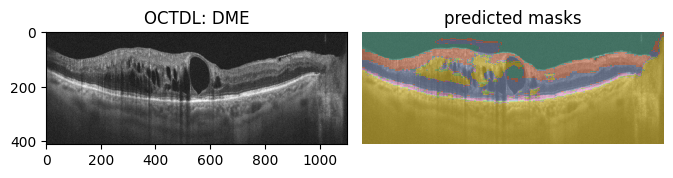

In [102]:
analysis('octdl/raw/dme_1434389_1.jpg', 'eval_outputs/dme_1434389_1_out.jpg', image_title='OCTDL: DME')

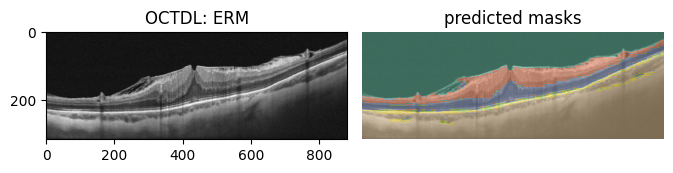

In [103]:
analysis('/home/kn445/rds/hpc-work/ml-oct/models/Pytorch-UNet/octdl/raw/erm_1811863_2.jpg', 'eval_outputs/erm_1811863_2_out.jpg', image_title='OCTDL: ERM')

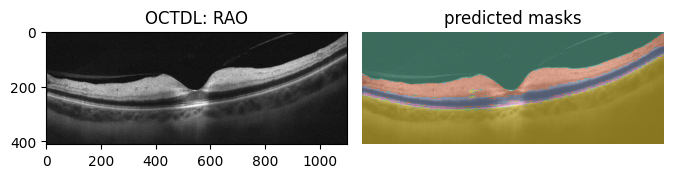

In [104]:
analysis('octdl/raw/rao_1013386_4.jpg', 'eval_outputs/rao_1013386_4_out.jpg', image_title='OCTDL: RAO')

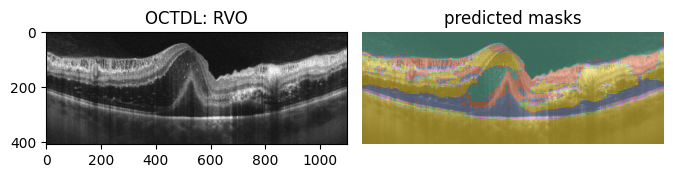

In [105]:
analysis('/home/kn445/rds/hpc-work/ml-oct/models/Pytorch-UNet/octdl/raw/rvo_1613227_1.jpg', 'eval_outputs/rvo_1613227_1_out.jpg', image_title='OCTDL: RVO')

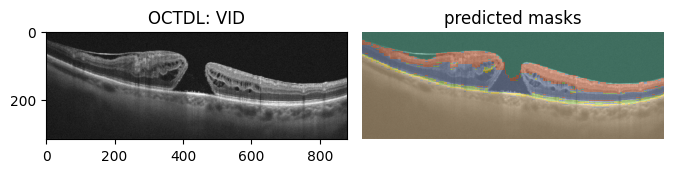

In [106]:
analysis('/home/kn445/rds/hpc-work/ml-oct/models/Pytorch-UNet/octdl/raw/vid_1416874_1.jpg', 'eval_outputs/vid_1416874_1_out.jpg', image_title='OCTDL: VID')

## Normal

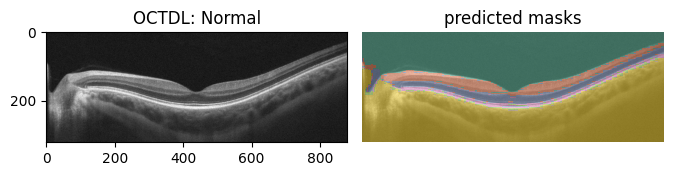

In [107]:
analysis('/home/kn445/rds/hpc-work/ml-oct/models/Pytorch-UNet/octdl/raw/no_1250592_2.jpg', 'eval_outputs/no_1250592_2_out.jpg', image_title='OCTDL: Normal')

## Box plot of metrics

In [ ]:
# https://earthdatascience.org/courses/intro-to-earth-data-science/python-code-fundamentals/work-with-files-directories-paths-in-python/os-glob-manipulate-file-paths/
# should I count all the metrics at once in this function?
def metrics_dist(true_msk_folder_path, pred_msk_folder_path, metric='DSC'):
  metrics = []
  labels=['BG/ILM','ILM-OPL','OPL-ISOS','ISOS-IBRPE','IBRPE-OBRPE','OBRPE/BG']
  true_msk_folder = true_msk_folder_path
  pred_msk_folder = pred_msk_folder_path

  true_msks_path = glob(os.path.join(true_msk_folder,'*'))
  pred_msks_path = glob(os.path.join(pred_msk_folder,'*'))
  true_msks_path.sort()
  pred_msks_path.sort()

  # check
  # print(true_msks_path)
  # print(len(true_msks_path))
  # print(pred_msks_path)
  # print(len(pred_msks_path))


  if metric == 'DSC':
    for true_msk_path, pred_msk_path in zip(true_msks_path, pred_msks_path) :
      # calculate DSC
      true_mask = ski.io.imread(true_msk_path)
      pred_mask = ski.io.imread(pred_msk_path)
      metric_list = evaluate(true_mask, pred_mask, metric='DSC', multi_class=True, n_classes=6)
      metrics.append(metric_list.tolist())

    # print(metrics)
    df_metrics = pd.DataFrame(metrics, columns=labels)

  if metric == 'IoU':
    for true_msk_path, pred_msk_path in zip(true_msks_path, pred_msks_path) :
      # calculate DSC
      true_mask = ski.io.imread(true_msk_path)
      pred_mask = ski.io.imread(pred_msk_path)
      metric_list = evaluate(true_mask, pred_mask, metric='IoU', multi_class=True, n_classes=6)
      metrics.append(metric_list.tolist())

    # print(metrics)
    df_metrics = pd.DataFrame(metrics, columns=labels)

  if metric == 'SENS':
    for true_msk_path, pred_msk_path in zip(true_msks_path, pred_msks_path) :
      # calculate DSC
      true_mask = ski.io.imread(true_msk_path)
      pred_mask = ski.io.imread(pred_msk_path)
      metric_list = evaluate(true_mask, pred_mask, metric='SENS', multi_class=True, n_classes=6)
      metrics.append(metric_list.tolist())

    # print(metrics)
    df_metrics = pd.DataFrame(metrics, columns=labels)

  if metric == 'SPEC':
    for true_msk_path, pred_msk_path in zip(true_msks_path, pred_msks_path) :
      # calculate DSC
      true_mask = ski.io.imread(true_msk_path)
      pred_mask = ski.io.imread(pred_msk_path)
      metric_list = evaluate(true_mask, pred_mask, metric='SPEC', multi_class=True, n_classes=6)
      metrics.append(metric_list.tolist())

    # print(metrics)
    df_metrics = pd.DataFrame(metrics, columns=labels)
  
  return df_metrics


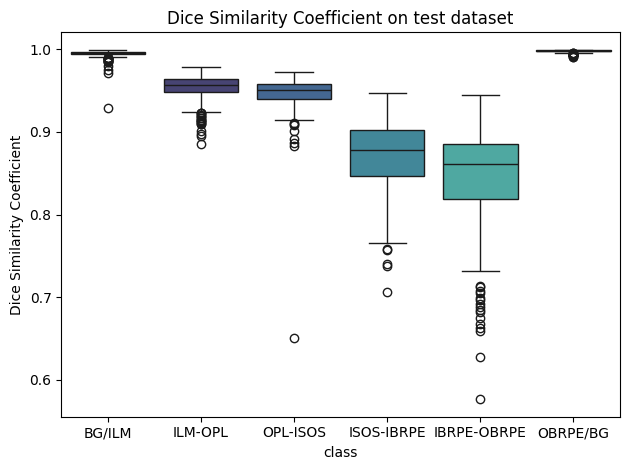

In [123]:
dsc_dist = metrics_dist('test_masks/', 'eval_outputs/test_outputs/', metric='DSC')

sns.boxplot(dsc_dist, palette='mako')
plt.ylabel('Dice Similarity Coefficient')
plt.xlabel('class')
plt.title('Dice Similarity Coefficient on test dataset')
plt.tight_layout()
plt.show()

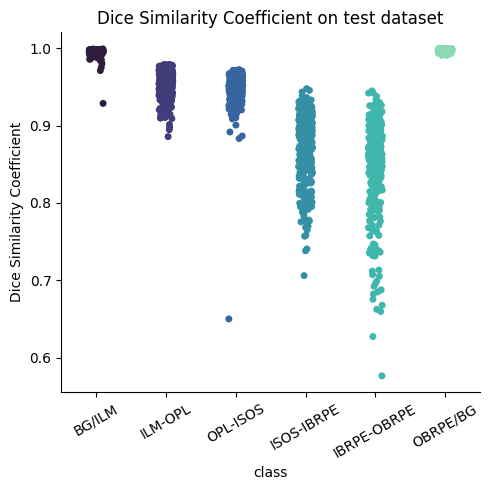

In [140]:
# cat plot
# https://stackoverflow.com/questions/63909351/how-to-rotate-xticklabels-in-a-seaborn-catplot
# https://www.geeksforgeeks.org/python/rotate-axis-tick-labels-in-seaborn-and-matplotlib/
g = sns.catplot(dsc_dist, palette='mako')
g.set_xticklabels(rotation=30)
plt.ylabel('Dice Similarity Coefficient')
plt.xlabel('class')
plt.title('Dice Similarity Coefficient on test dataset')
plt.tight_layout()
plt.show()

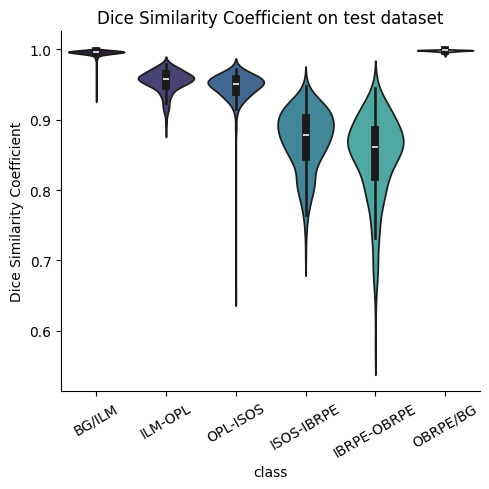

In [141]:
# violin plot https://github.com/mwaskom/seaborn/blob/f04b6cd5484267a0885d1fed068e99dff3a1b226/seaborn/categorical.py#L642
g = sns.catplot(dsc_dist, kind='violin', palette='mako')
g.set_xticklabels(rotation=30)
plt.ylabel('Dice Similarity Coefficient')
plt.xlabel('class')
plt.title('Dice Similarity Coefficient on test dataset')
plt.tight_layout()
plt.show()

In [144]:
iou_dist = metrics_dist('test_masks/', 'eval_outputs/test_outputs/', metric='IoU')
sens_dist = metrics_dist('test_masks/', 'eval_outputs/test_outputs/', metric='SENS')
spec_dist = metrics_dist('test_masks/', 'eval_outputs/test_outputs/', metric='SPEC')

Text(0.5, 1.0, 'Specificity on test dataset')

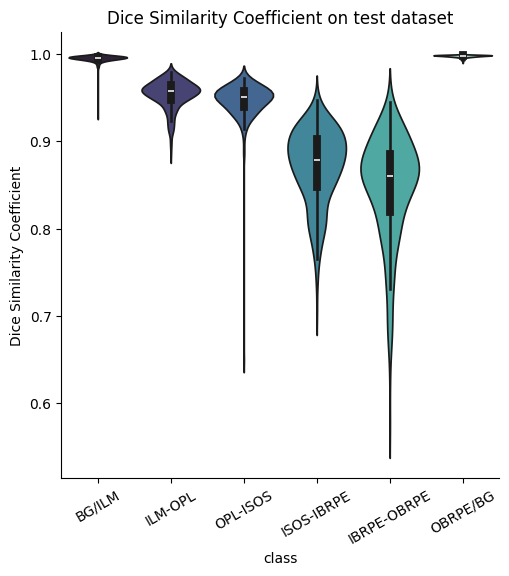

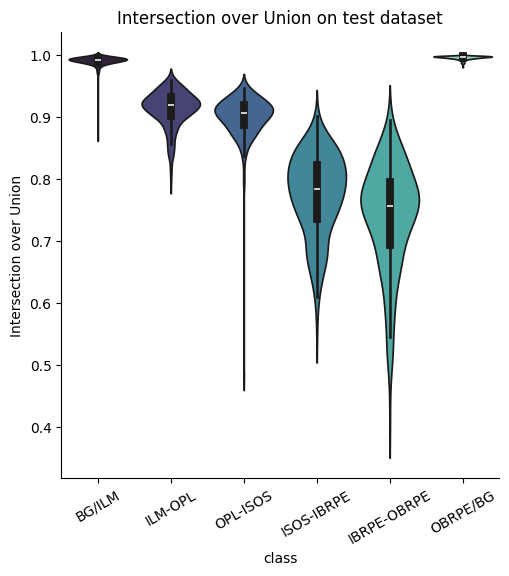

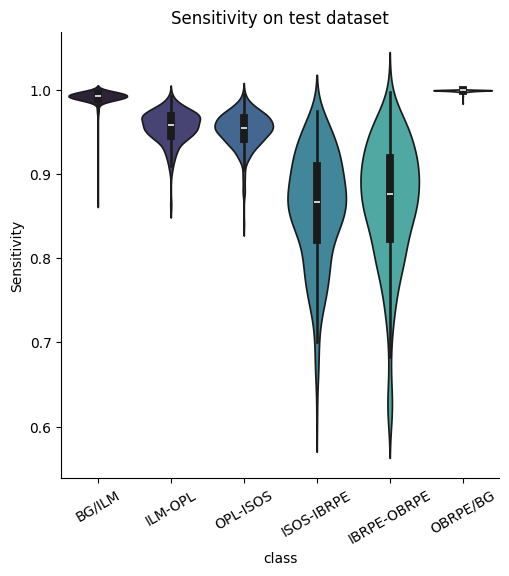

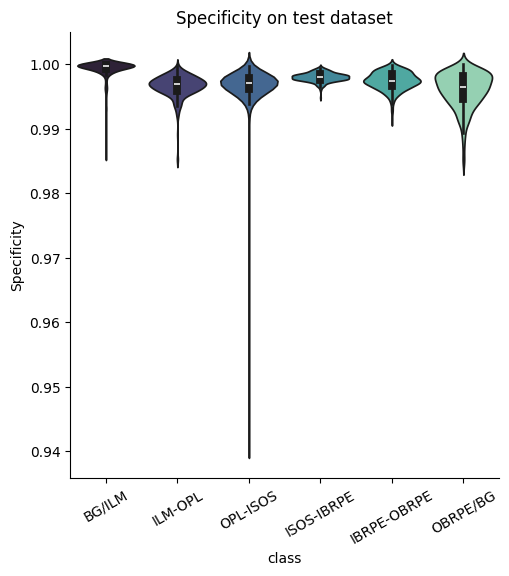

In [145]:
# https://stackoverflow.com/questions/63909351/how-to-rotate-xticklabels-in-a-seaborn-catplot
# https://www.geeksforgeeks.org/python/rotate-axis-tick-labels-in-seaborn-and-matplotlib/

g = sns.catplot(dsc_dist, kind='violin', palette='mako')
g.set_xticklabels(rotation=30)
plt.ylabel('Dice Similarity Coefficient')
plt.xlabel('class')
plt.title('Dice Similarity Coefficient on test dataset')




g = sns.catplot(iou_dist, kind='violin', palette='mako')
g.set_xticklabels(rotation=30)
plt.ylabel('Intersection over Union')
plt.xlabel('class')
plt.title('Intersection over Union on test dataset')



g = sns.catplot(sens_dist, kind='violin', palette='mako')
g.set_xticklabels(rotation=30)
plt.ylabel('Sensitivity')
plt.xlabel('class')
plt.title('Sensitivity on test dataset')



g = sns.catplot(spec_dist, kind='violin', palette='mako')
g.set_xticklabels(rotation=30)
plt.ylabel('Specificity')
plt.xlabel('class')
plt.title('Specificity on test dataset')


# # check
# print('IoU first five rows')
# print(pd.DataFrame.head(iou_dist))

# print('DSC first five rows')
# print(pd.DataFrame.head(dsc_dist))
